## Road Surface Classification with ResNet
This notebook trains a ResNet model on the road surface dataset.

In [1]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torchvision import datasets
from torch.utils.data import DataLoader
from src.datasets.road_loader import sample_road_surface_dataset

## Import ResNet Functions

In [3]:
from src.models.resnet_cnn import (
    create_resnet18,
    get_default_transforms,
    train_epoch,
    validate_epoch,
    predict_image,
    get_all_predictions
)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Load Road Surface Dataset

In [4]:
# Sample the dataset to match doggie dataset sizes (160 train, 3 val, 10 test per class)
# This reduces ~4M images to ~4K train, ~75 val, ~250 test for 25 classes
# Run this once to create the sampled dataset
base_data = Path('../data/road_surface/RSCD dataset-1million')
sampled_data = Path('../data/road_surface/RSCD_sampled')
if not sampled_data.exists():
    print("Creating sampled dataset...")
    sample_road_surface_dataset(base_data, sampled_data, train_per_class=160, val_per_class=3, test_per_class=10)
    print("Sampling complete!")
else:
    print(f"Sampled dataset already exists at {sampled_data}")

Sampled dataset already exists at ../data/road_surface/RSCD_sampled


In [5]:
data_path = Path('../data/road_surface/RSCD_sampled')
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=data_path/'train', transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_path/'val', transform=val_transform)
test_dataset = datasets.ImageFolder(root=data_path/'test', transform=val_transform)
class_names = train_dataset.classes
num_classes = len(class_names)
print(f'Number of classes: {num_classes}')
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Number of classes: 27
Train samples: 4320
Val samples: 81
Test samples: 270


In [6]:
batch_size = 16
print(f'Using batch size: {batch_size}')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Using batch size: 16
Train batches: 270
Validation batches: 6
Test batches: 17


In [7]:
model = create_resnet18(num_classes=num_classes)
# Apple Silicon GPU (MPS) support
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using Apple Silicon GPU (MPS) acceleration!')
else:
    device = torch.device('cpu')
    print('MPS not available, using CPU.')
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'trainable parameters: {trainable_params:,}')

Using Apple Silicon GPU (MPS) acceleration!
Total parameters: 11,453,019
trainable parameters: 11,453,019


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
print('Loss function: CrossEntropyLoss')
print('Optimizer: Adam (lr=0.0001, weight_decay=1e-4)')
print('Scheduler: ReduceLROnPlateau')

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.0001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau


Loaded model weights from best_road_surface_model.pth
Loaded training history for 100 epochs.


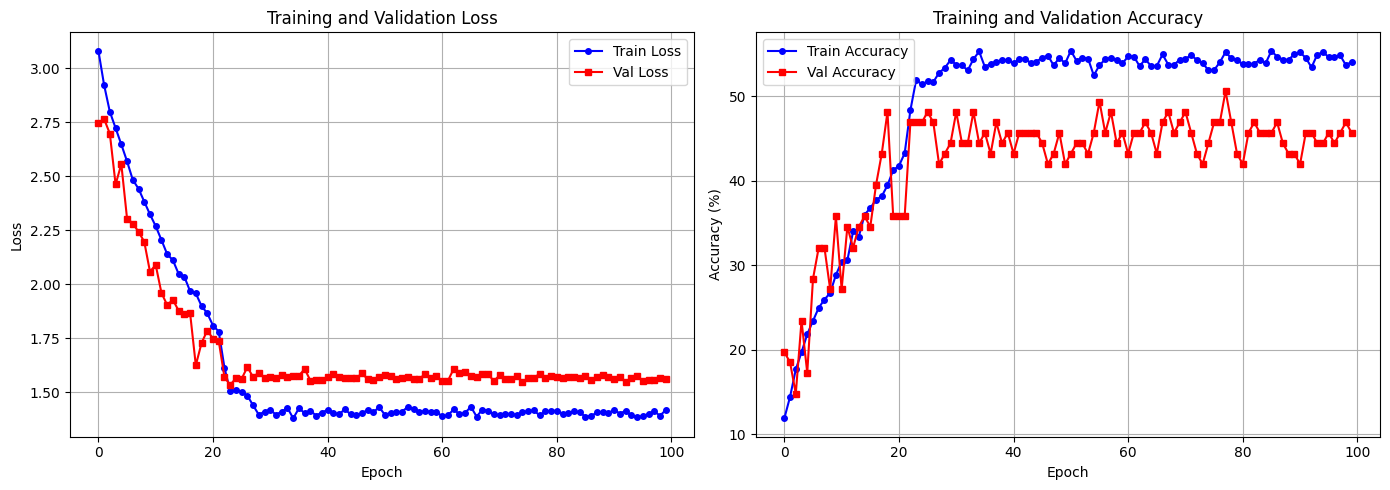

In [9]:
# Load last saved model and training history
import torch
import os
import json
import matplotlib.pyplot as plt

model_path = 'best_road_surface_model.pth'
history_path = 'road_surface_training_history.json'

# Load model
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"Loaded model weights from {model_path}")
else:
    print("No saved model found.")

# Load training history
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    train_losses = history['train_losses']
    val_losses = history['val_losses']
    train_accs = history['train_accs']
    val_accs = history['val_accs']
    num_epochs = len(train_losses)
    print(f"Loaded training history for {num_epochs} epochs.")
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, 'b-o', label='Train Loss', markersize=4)
    ax1.plot(val_losses, 'r-s', label='Val Loss', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    ax2.plot(train_accs, 'b-o', label='Train Accuracy', markersize=4)
    ax2.plot(val_accs, 'r-s', label='Val Accuracy', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No training history found.")

Resuming from epoch 100


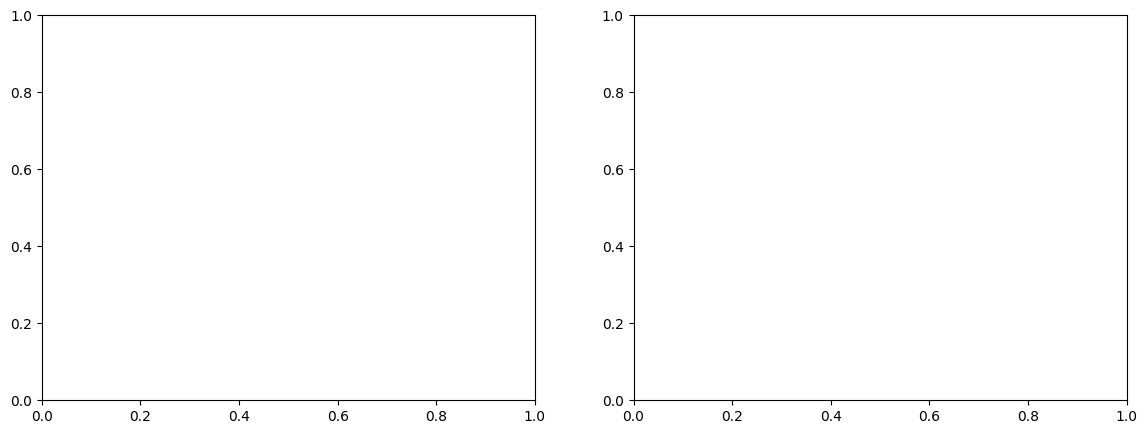

In [10]:
# Live updating training/validation accuracy and loss plot with device fix
%matplotlib inline
import matplotlib.pyplot as plt
import json
plt.ion()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

history_path = 'road_surface_training_history.json'

# Load previous history if exists
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    train_losses = history.get('train_losses', [])
    val_losses = history.get('val_losses', [])
    train_accs = history.get('train_accs', [])
    val_accs = history.get('val_accs', [])
    start_epoch = len(train_losses)
    print(f"Resuming from epoch {start_epoch}")
    # Set best_val_acc to max historical value if available
    best_val_acc = max(val_accs) if val_accs else 0.0
else:
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    start_epoch = 0
    best_val_acc = 0.0

num_epochs = 100

for epoch in range(start_epoch, num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 30)
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step(val_loss)
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_road_surface_model.pth')
        print(f'✓ Saved best model (val_acc: {val_acc:.2f}%)')
    # Save history after each epoch
    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    with open(history_path, 'w') as f:
        json.dump(history, f)
    # Live plot update
    ax1.clear()
    ax1.plot(train_losses, 'b-o', label='Train Loss', markersize=4)
    ax1.plot(val_losses, 'r-s', label='Val Loss', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    ax2.clear()
    ax2.plot(train_accs, 'b-o', label='Train Accuracy', markersize=4)
    ax2.plot(val_accs, 'r-s', label='Val Accuracy', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.pause(0.1)
    plt.show()
plt.ioff()
plt.savefig('road_surface_training_history.png', dpi=150)
plt.show()

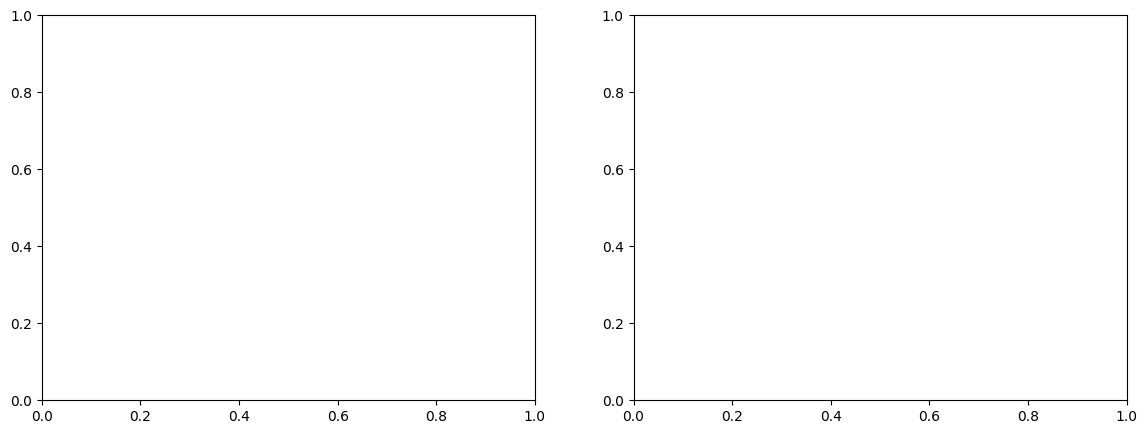

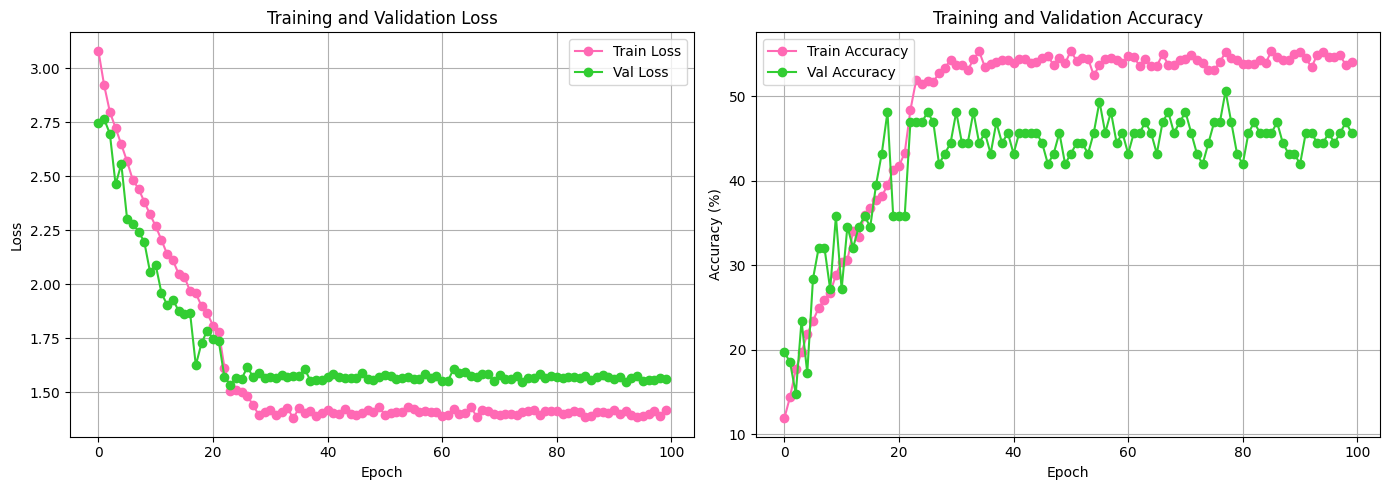

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, color='hotpink', marker='o', label='Train Loss', markersize=6)
ax1.plot(val_losses, color='limegreen', marker='o', label='Val Loss', markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)
ax2.plot(train_accs, color='hotpink', marker='o', label='Train Accuracy', markersize=6)
ax2.plot(val_accs, color='limegreen', marker='o', label='Val Accuracy', markersize=6)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig('road_surface_training_history.png', dpi=150)
plt.show()

In [12]:
print('='*50)
print('TEST SET EVALUATION')
print('='*50)
model.load_state_dict(torch.load('best_road_surface_model.pth'))
test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
print(f'Final Test Results:')
print(f'  Test Loss: {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.2f}%')

TEST SET EVALUATION


Validation: 100%|██████████| 17/17 [00:00<00:00, 23.86it/s, Loss=1.0932, Acc=52.22%]

Final Test Results:
  Test Loss: 1.4962
  Test Accuracy: 52.22%


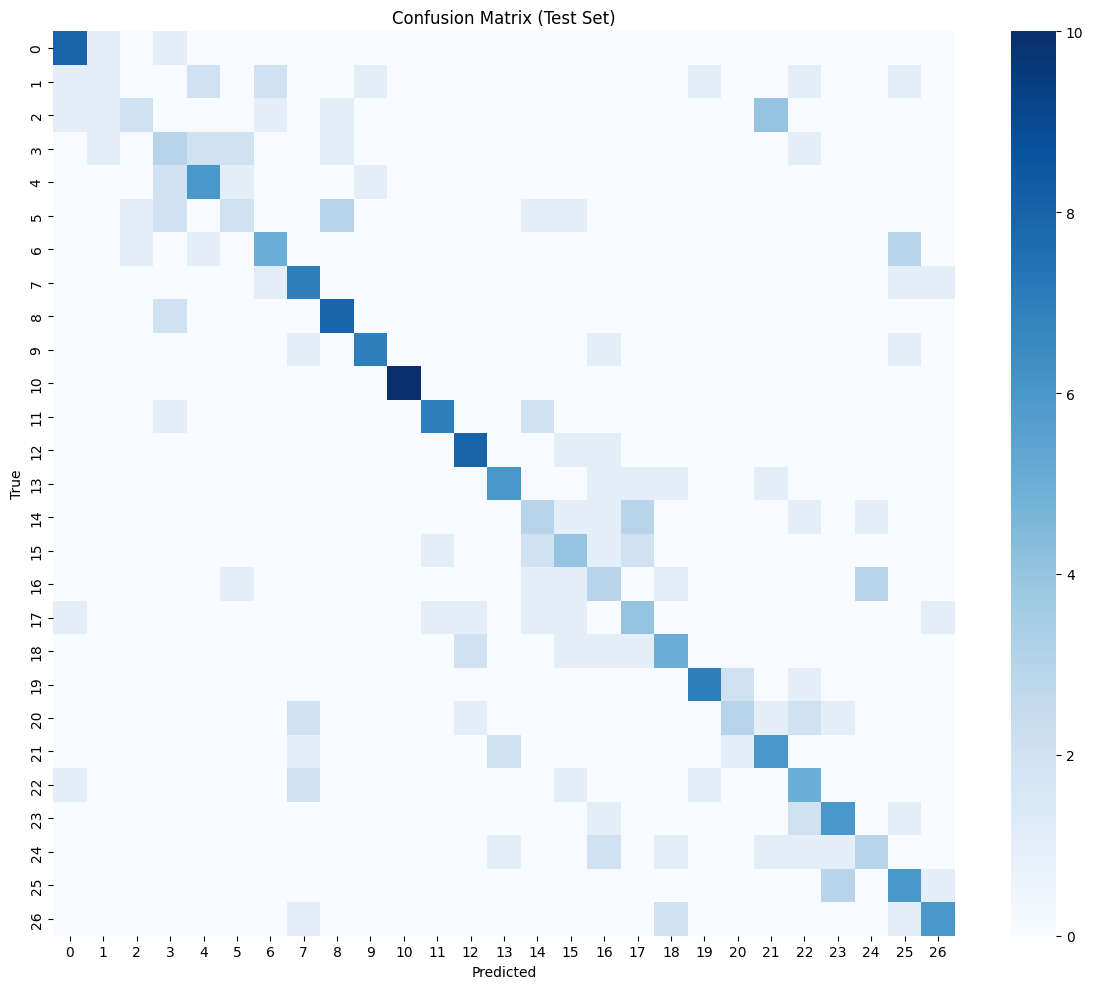

Mean class accuracy: 0.5222


In [13]:
# Test evaluation and confusion matrix with device fix
test_preds, test_labels = get_all_predictions(model, test_loader, device)
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
class_acc = cm.diagonal() / cm.sum(axis=1)
print(f'Mean class accuracy: {np.nanmean(class_acc):.4f}')

In [17]:
test_idx = random.randint(0, len(test_dataset) - 1)
img_path, true_label = test_dataset.samples[test_idx]
true_class = class_names[true_label]
pred_class, confidence = predict_image(img_path, model, class_names, val_transform, device)
print(f'True class: {true_class}')
print(f'Predicted: {pred_class}')
print(f'Confidence: {confidence:.4f} ({confidence*100:.2f}%)')

True class: water_asphalt_slight
Predicted: water_asphalt_slight
Confidence: 0.5710 (57.10%)


In [23]:
# List class names 6-13 (Python uses 0-based indexing)
print(class_names)

['dry_asphalt_severe', 'dry_asphalt_slight', 'dry_asphalt_smooth', 'dry_concrete_severe', 'dry_concrete_slight', 'dry_concrete_smooth', 'dry_gravel', 'dry_mud', 'fresh_snow', 'ice', 'melted_snow', 'water_asphalt_severe', 'water_asphalt_slight', 'water_asphalt_smooth', 'water_concrete_severe', 'water_concrete_slight', 'water_concrete_smooth', 'water_gravel', 'water_mud', 'wet_asphalt_severe', 'wet_asphalt_slight', 'wet_asphalt_smooth', 'wet_concrete_severe', 'wet_concrete_slight', 'wet_concrete_smooth', 'wet_gravel', 'wet_mud']


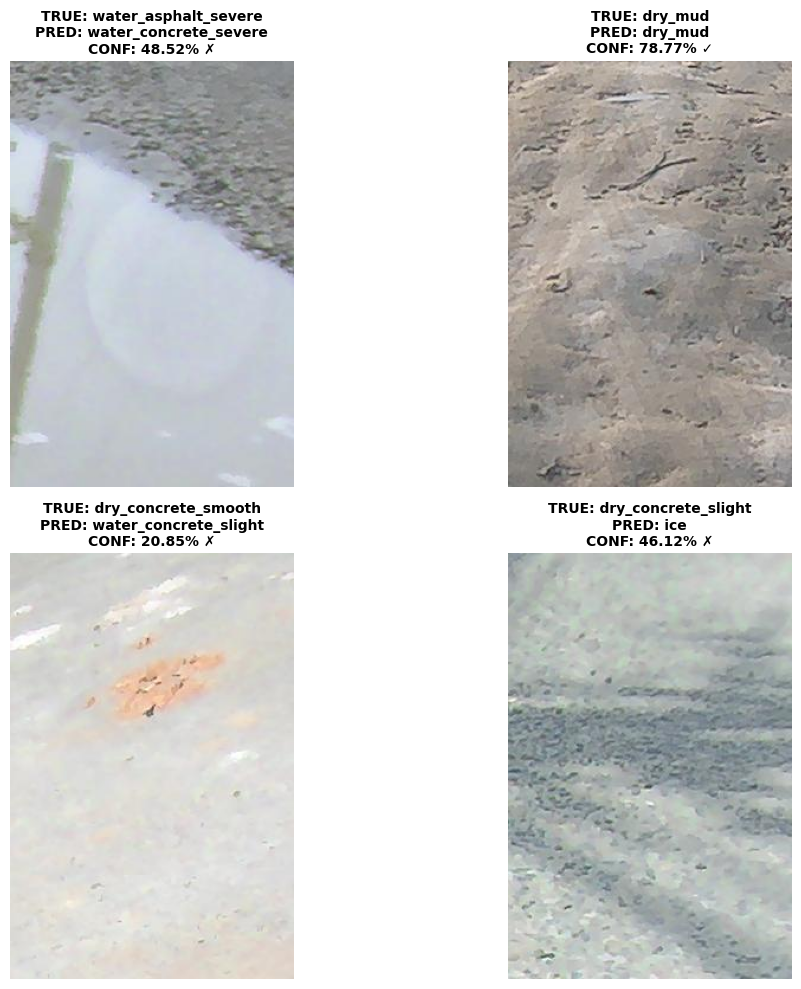

In [24]:
import random
from PIL import Image

# Get 4 random test samples
num_samples = 4
random_indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for idx_plot, test_idx in enumerate(random_indices):
        img_path, true_label = test_dataset.samples[test_idx]
        true_class = class_names[true_label]
        
        # Load and predict
        image = Image.open(img_path)
        pred_class, confidence = predict_image(img_path, model, class_names, val_transform, device)
        
        # Display
        ax = axes[idx_plot]
        ax.imshow(image)
        ax.axis('off')
        
        # Color border: green if correct, red if wrong
        border_color = 'lime' if true_class == pred_class else 'red'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            spine.set_visible(True)
        
        # Title with predictions
        title = f"TRUE: {true_class}\n"
        title += f"PRED: {pred_class}\n"
        title += f"CONF: {confidence:.2%}"
        if true_class == pred_class:
            title += " ✓"
        else:
            title += " ✗"
        ax.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()